# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
pd.options.mode.chained_assignment = None
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Sumber dataset: https://archive.ics.uci.edu/dataset/222/bank+marketing

df = pd.read_csv("bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [5]:
print("Missing values per kolom:")
print(df.isnull().sum())

print("\nJumlah data duplikat:", df.duplicated().sum())

Missing values per kolom:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Jumlah data duplikat: 0


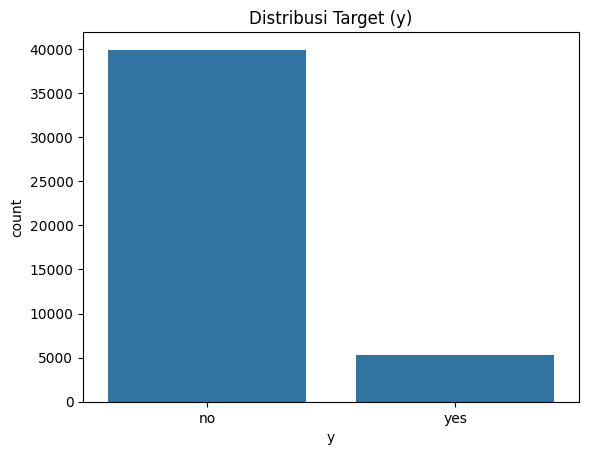

In [6]:
# Distribusi variabel target (y)
sns.countplot(x='y', data=df)
plt.title("Distribusi Target (y)")
plt.show()

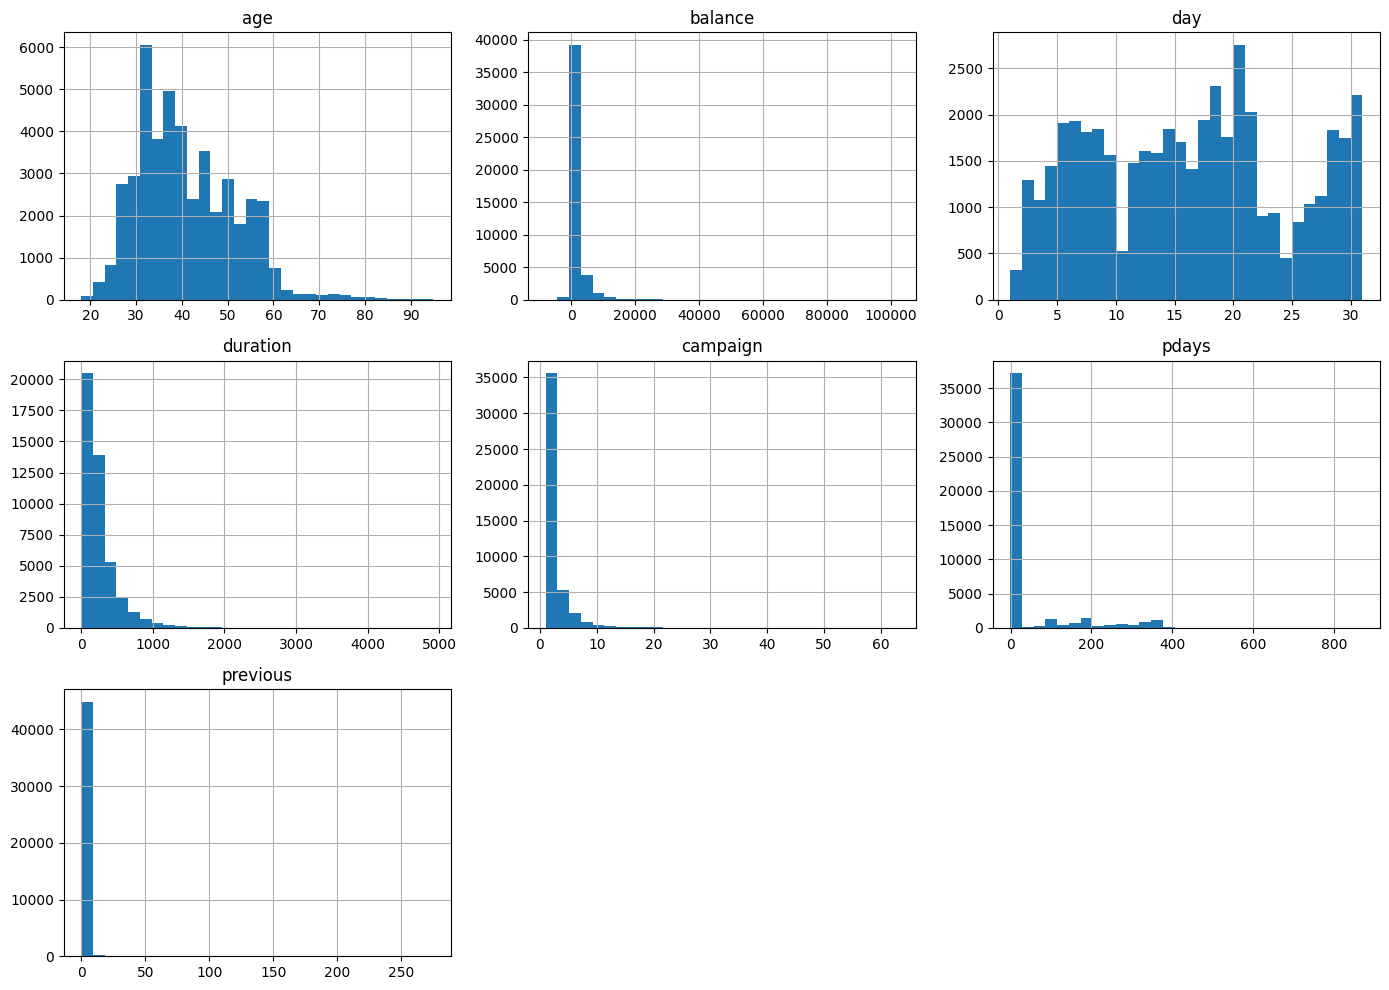

In [7]:
# Distribusi fitur numerik
num_cols = df.select_dtypes(include='number').columns

df[num_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

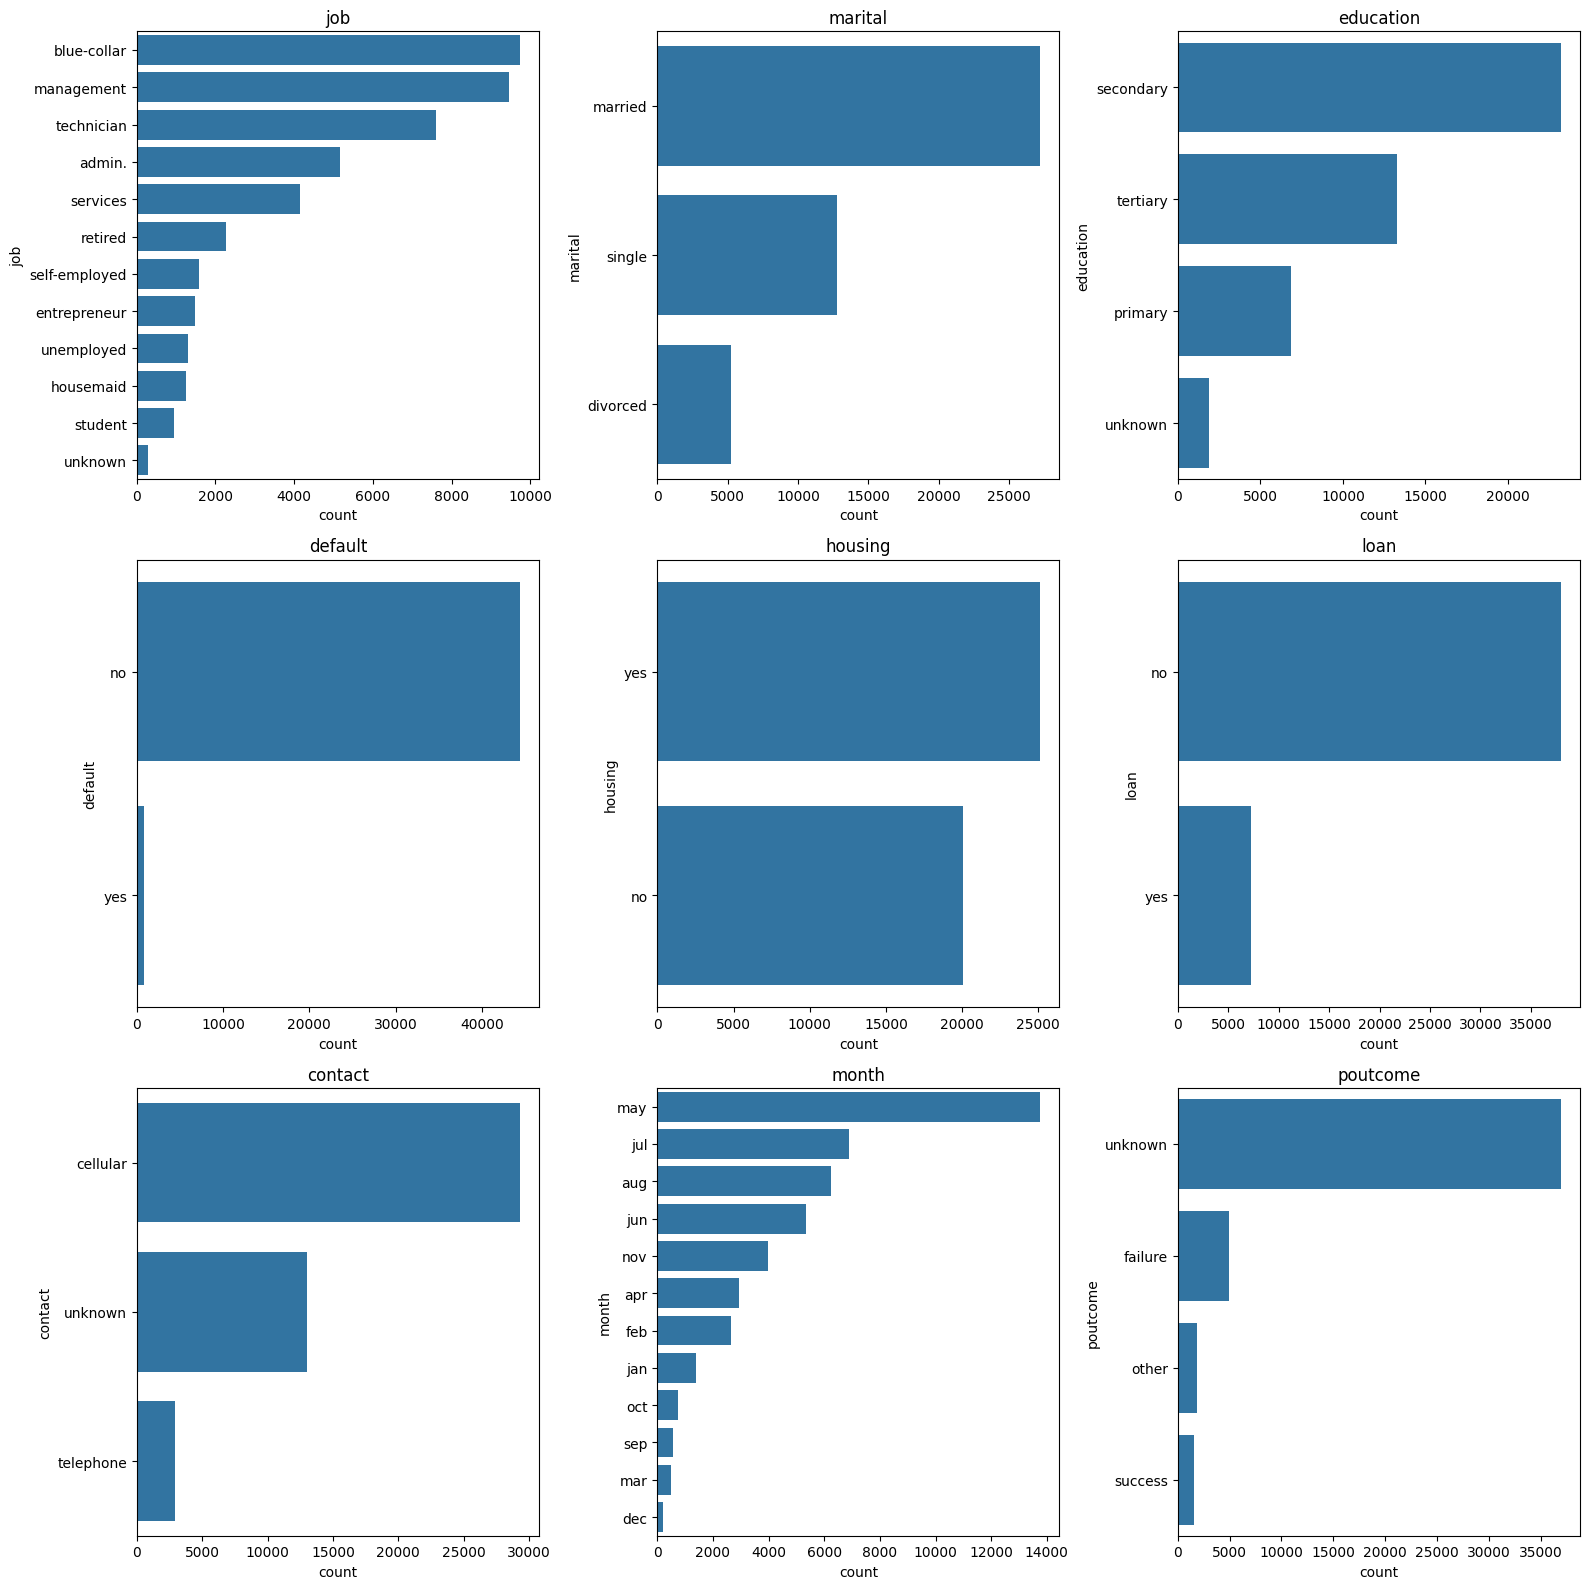

In [8]:
# Distribusi fitur kategorikal
cat_cols = df.select_dtypes(include='object').columns.drop('y')

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 16))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(y=col, data=df, order=df[col].value_counts().index, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

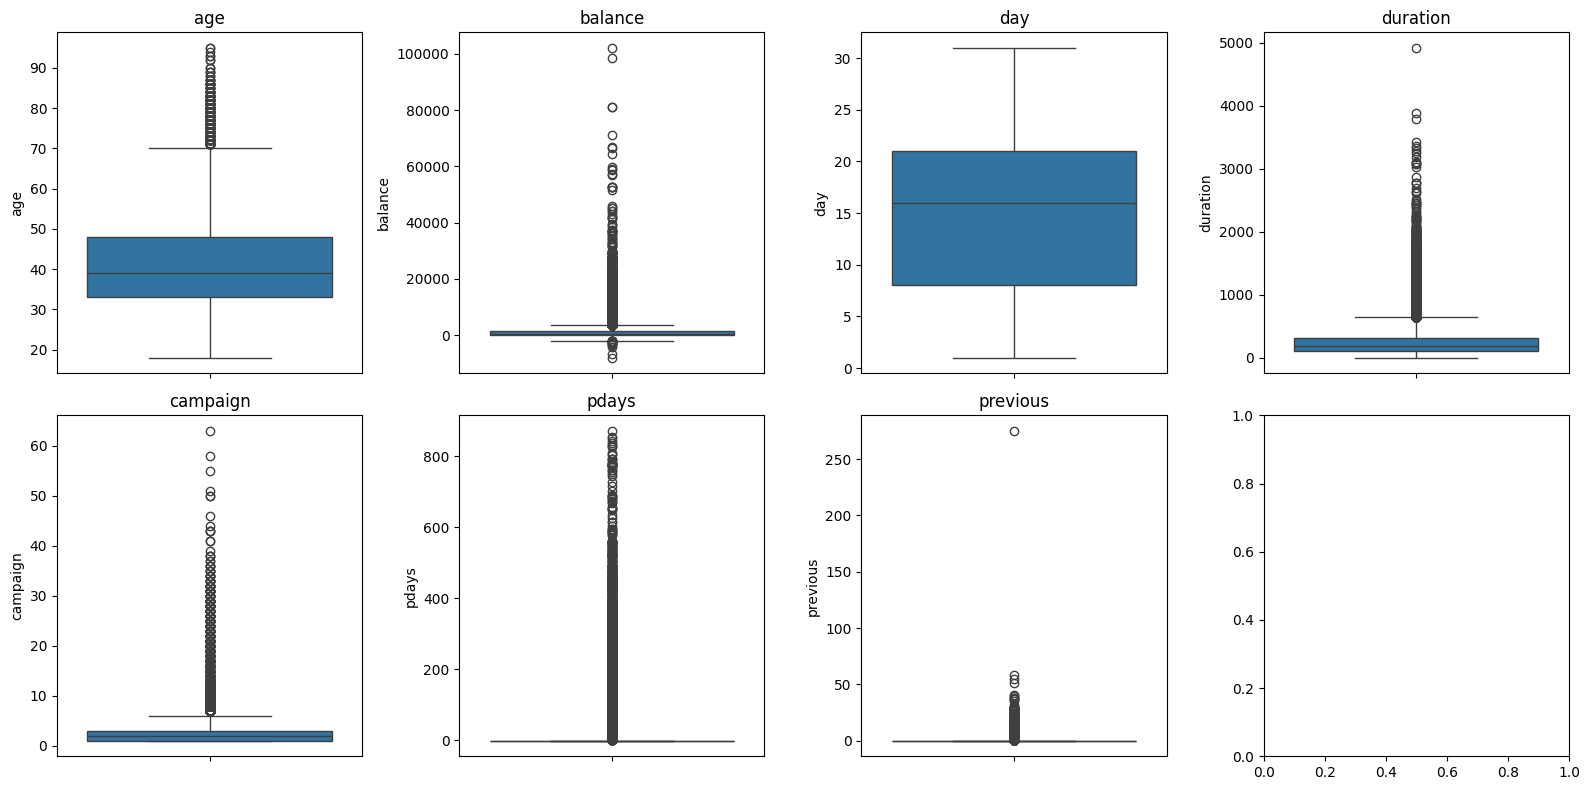

In [9]:
# Deteksi outlier pada fitur numerik
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [10]:
# Pada kode ini, fitur "Duration" dihilangkan untuk membangun model prediktif yang realistis sesuai dengan saran beberapa jurnal dengan dataset yang sama
# https://pmc.ncbi.nlm.nih.gov/articles/PMC7518195/
# https://link.springer.com/article/10.1007/s00521-023-08204-w

# Berdasarkan analisis saya pada data kategori untuk fitur 'eduacation', fitur tersebut merupakan ordinal
# sehingga dilakukan label encoding sedangkan sisanya merupakan nominal sehingga dilakukan one hot encoding
# refrensi label encoding: https://www.sciencedirect.com/org/science/article/pii/S1546221824007483

class DataFrameSelector(BaseEstimator, TransformerMixin):
    """Memilih kolom tertentu dari DataFrame agar bisa dipakai dalam Pipeline sklearn."""
    def __init__(self, attribute_names):
        self.attribute_names = attribute_names

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.attribute_names].values

def preprocessing(df):
    """
    Melakukan preprocessing dataset Bank Marketing.
    Tahapan:
    1. Menghapus kolom 'duration'.
    2. Encoding target 'y' menjadi biner (1 = yes, 0 = no).
    3. Pipeline fitur:
       - numerik      -> StandardScaler
       - education    -> OrdinalEncoder (ordinal)
       - kategorikal nominal lainnya -> OneHotEncoder

    Parameters
    ----------
    df : pd.DataFrame
        Dataset mentah (hasil load_data).

    Returns
    -------
    pd.DataFrame
        Data hasil preprocessing.
    """
    df = df.copy()

    # 1. Menghapus kolom 'duration'
    df = df.drop(columns=['duration'])

    # 2. Encoding target 'y' menjadi biner
    df['y'] = df['y'].map({'yes': 1, 'no': 0})

    X = df.drop(columns=['y'])
    y = df['y']

    # Nama fitur langsung ditentukan (hardcode), tidak diturunkan secara dinamis
    numeric_features = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
    ordinal_features = ['education']
    nominal_features = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

    # 3. Pipeline per kelompok fitur
    numerical_pipeline = Pipeline([
        ("select_numeric", DataFrameSelector(numeric_features)),
        ("std_scaler", StandardScaler()),
    ])

    ordinal_pipeline = Pipeline([
        ("select_ordinal", DataFrameSelector(ordinal_features)),
        ("ordinal_encoder", OrdinalEncoder(categories=[['unknown', 'primary', 'secondary', 'tertiary']])),
    ])

    nominal_pipeline = Pipeline([
        ("select_nominal", DataFrameSelector(nominal_features)),
        ("onehot_encoder", OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
    ])

    full_pipeline = FeatureUnion(transformer_list=[
        ("numerical_pipeline", numerical_pipeline),
        ("ordinal_pipeline", ordinal_pipeline),
        ("nominal_pipeline", nominal_pipeline),
    ])

    X_processed = full_pipeline.fit_transform(X)

    # Susun kembali nama kolom hasil transformasi
    onehot_columns = full_pipeline.transformer_list[2][1].named_steps["onehot_encoder"] \
        .get_feature_names_out(nominal_features)
    feature_names = numeric_features + ordinal_features + list(onehot_columns)

    df_processed = pd.DataFrame(X_processed, columns=feature_names, index=X.index)
    df_processed['y'] = y.values

    return df_processed

df_preprocessed = preprocessing(df)
df_preprocessed.to_csv("bank-full_preprocessing.csv", index=False)
df_preprocessed.head()


,age,balance,day,campaign,pdays,previous,education,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,y
0,1.606965,0.256419,-1.298476,-0.569351,-0.411453,-0.25194,3.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
1,0.288529,-0.437895,-1.298476,-0.569351,-0.411453,-0.25194,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
2,-0.747384,-0.446762,-1.298476,-0.569351,-0.411453,-0.25194,2.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3,0.571051,0.047205,-1.298476,-0.569351,-0.411453,-0.25194,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,-0.747384,-0.447091,-1.298476,-0.569351,-0.411453,-0.25194,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
